# EDA — PAD-UFES-20

Análisis exploratorio del dataset de lesiones de piel (imágenes clínicas + datos tabulares).
Objetivo: entender el target, el desbalance, los valores faltantes, las variables clínicas y
la estructura por paciente, para fundamentar el split y el modelado posteriores.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.data.dataset import load_dataset
from src.data.dataset_utils import CLASSES, MALIGNANT, index_images, integrity_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga e integridad del dataset

In [2]:
df = load_dataset()
integrity_report(df, index_images())

{'n_rows': 2298,
 'n_images_found': 2298,
 'n_missing_images': 0,
 'n_orphan_images': 0,
 'missing_examples': [],
 'orphan_examples': []}

In [3]:
print("filas:", df.shape[0], "| columnas:", df.shape[1])
df.head()

filas: 2298 | columnas: 27


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,img_path
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARM,NaN,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False,/Users/alejandrodiaz/Documents/personal/Master...
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True,/Users/alejandrodiaz/Documents/personal/Master...
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACE,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False,/Users/alejandrodiaz/Documents/personal/Master...
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HAND,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False,/Users/alejandrodiaz/Documents/personal/Master...
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,False,1.0,FOREARM,5.0,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True,/Users/alejandrodiaz/Documents/personal/Master...


## 2. Variable objetivo

El target es `diagnostic` (6 clases). Miramos su distribución y la vista agrupada
maligno vs benigno (`{BCC, MEL, SCC}` vs el resto).

diagnostic
ACK    730
BCC    845
MEL     52
NEV    244
SCC    192
SEK    235
Name: count, dtype: int64


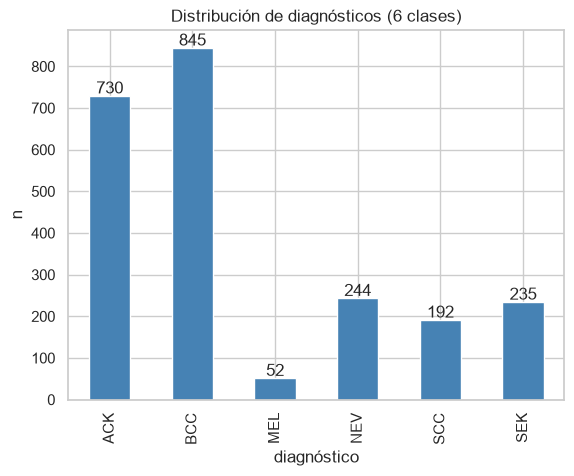

In [4]:
counts = df["diagnostic"].value_counts().reindex(CLASSES)
print(counts)

ax = counts.plot(kind="bar", color="steelblue")
ax.set_title("Distribución de diagnósticos (6 clases)")
ax.set_xlabel("diagnóstico"); ax.set_ylabel("n")
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha="center")
plt.show()

In [5]:
df["malignant"] = df["diagnostic"].isin(MALIGNANT)
print(df["malignant"].value_counts())
print((df["malignant"].value_counts(normalize=True) * 100).round(1))

malignant
False    1209
True     1089
Name: count, dtype: int64
malignant
False    52.6
True     47.4
Name: proportion, dtype: float64


## 3. Valores faltantes

Varias columnas clínicas tienen nulos. Los cuantificamos para decidir la estrategia de imputación.

background_mother      35.8
background_father      35.6
cancer_history         35.0
diameter_1             35.0
smoke                  35.0
drink                  35.0
pesticide              35.0
gender                 35.0
skin_cancer_history    35.0
has_piped_water        35.0
has_sewage_system      35.0
fitspatrick            35.0
diameter_2             35.0
dtype: float64


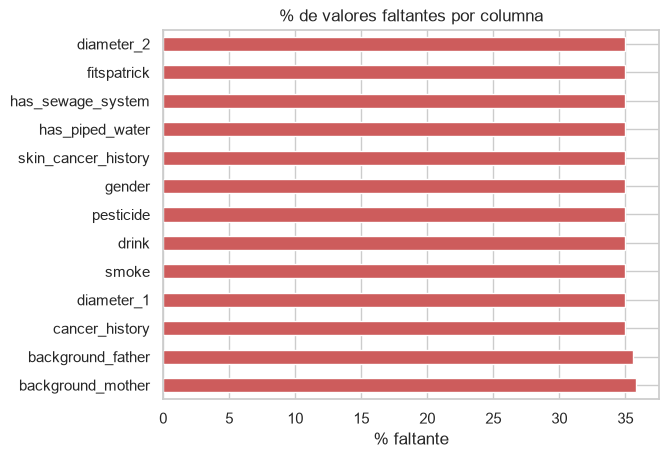

In [6]:
na = df.isna().mean().sort_values(ascending=False)
na = na[na > 0]
print((na * 100).round(1))

if len(na):
    ax = na.mul(100).plot(kind="barh", color="indianred")
    ax.set_title("% de valores faltantes por columna")
    ax.set_xlabel("% faltante")
    plt.show()

## 4. Variables numéricas

Edad y los dos diámetros de la lesión. Distribución global y por clase.

In [7]:
num_cols = ["age", "diameter_1", "diameter_2"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df[num_cols].describe()

,age,diameter_1,diameter_2
count,2298.000000,1494.000000,1494.000000
mean,60.464752,11.897055,8.852209
std,15.894866,8.634492,5.797036
min,6.000000,0.000000,0.000000
25%,52.000000,7.000000,5.000000
50%,62.000000,10.000000,8.000000
75%,72.000000,15.000000,10.000000
max,94.000000,100.000000,70.000000


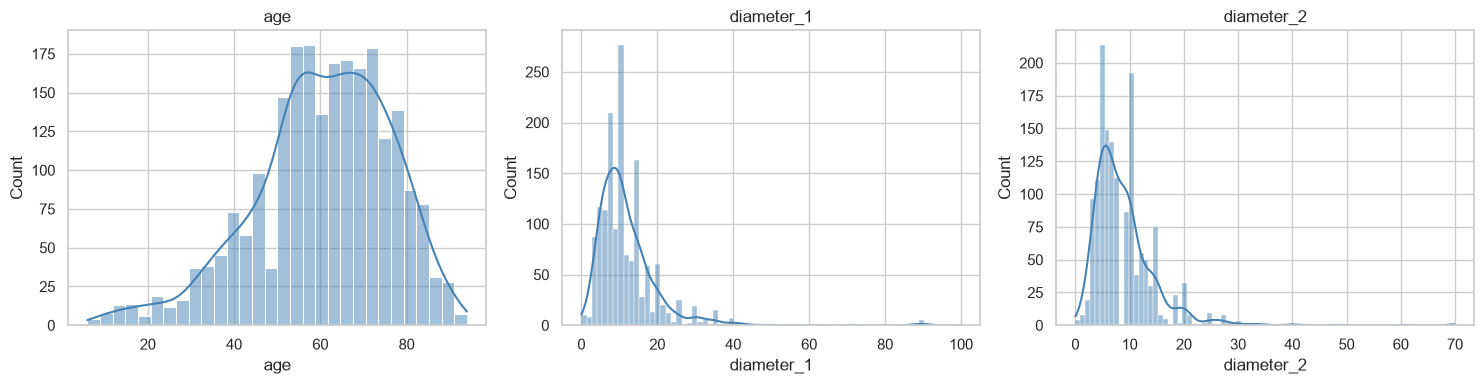

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c].dropna(), ax=ax, kde=True, color="steelblue")
    ax.set_title(c)
plt.tight_layout(); plt.show()

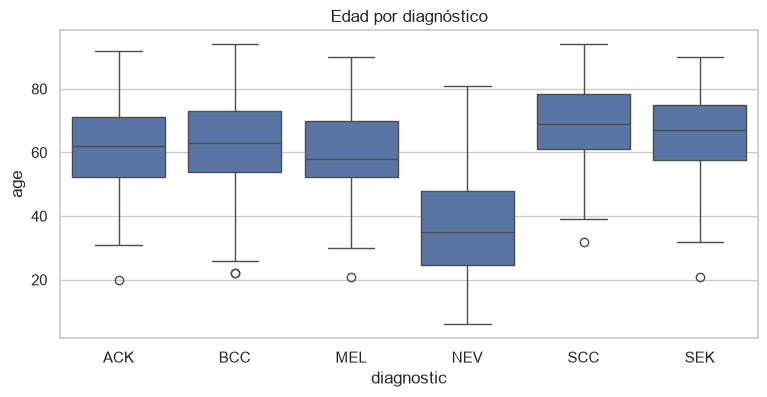

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="diagnostic", y="age", order=CLASSES, ax=ax)
ax.set_title("Edad por diagnóstico")
plt.show()

## 5. Variables categóricas y de contexto

In [10]:
cat_cols = ["gender", "region", "fitspatrick", "smoke", "drink",
            "skin_cancer_history", "cancer_history", "pesticide",
            "has_piped_water", "has_sewage_system"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False).head(10))
    print()

--- gender ---
gender
NaN       804
FEMALE    753
MALE      741
Name: count, dtype: int64

--- region ---
region
FACE       570
FOREARM    392
CHEST      280
BACK       248
ARM        192
NOSE       158
HAND       126
NECK        93
THIGH       73
EAR         73
Name: count, dtype: int64

--- fitspatrick ---
fitspatrick
2.0    876
NaN    804
3.0    392
1.0    153
4.0     62
5.0     10
6.0      1
Name: count, dtype: int64

--- smoke ---
smoke
False    1292
NaN       804
True      202
Name: count, dtype: int64

--- drink ---
drink
False    1126
NaN       804
True      368
Name: count, dtype: int64

--- skin_cancer_history ---
skin_cancer_history
False    813
NaN      804
True     681
Name: count, dtype: int64

--- cancer_history ---
cancer_history
NaN      804
True     779
False    715
Name: count, dtype: int64

--- pesticide ---
pesticide
False    897
NaN      804
True     597
Name: count, dtype: int64

--- has_piped_water ---
has_piped_water
True     923
NaN      804
False    571
Name:

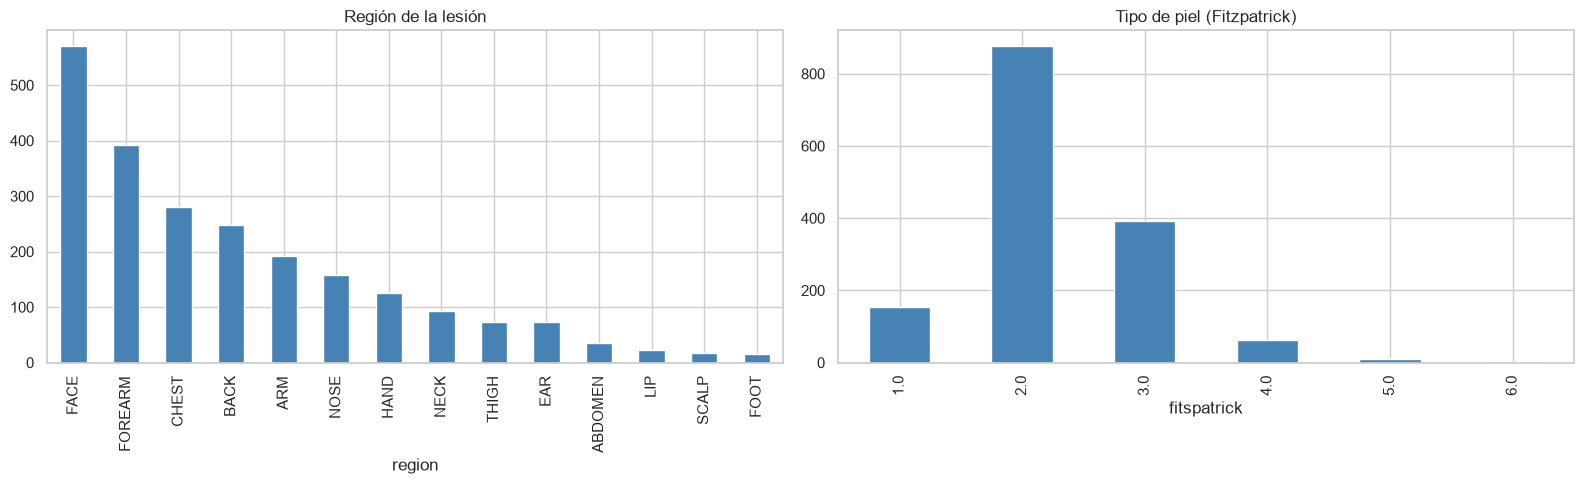

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["region"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Región de la lesión")
df["fitspatrick"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Tipo de piel (Fitzpatrick)")
plt.tight_layout(); plt.show()

## 6. Síntomas clínicos de la lesión

Señales booleanas (pica, creció, duele, cambió, sangra, elevación). Vemos su prevalencia
y si se asocian con malignidad.

In [12]:
symptom_cols = ["itch", "grew", "hurt", "changed", "bleed", "elevation"]
rate = (df.groupby("malignant")[symptom_cols]
          .apply(lambda g: (g == "True").mean()))
print(rate.round(2).T)

df[symptom_cols].apply(lambda s: s.value_counts()).T

malignant  False  True 
itch        0.54   0.73
grew        0.32   0.50
hurt        0.04   0.31
changed     0.05   0.13
bleed       0.08   0.47
elevation   0.45   0.81


,False,True,UNK
itch,837,1455,6
grew,971,925,402
hurt,1891,397,10
changed,1700,202,396
bleed,1678,614,6
elevation,863,1433,2


## 7. Estructura por paciente (justifica el split agrupado)

Un mismo paciente puede tener varias lesiones e imágenes. Si al hacer el split un paciente
cayera en train y en test a la vez, habría **data leakage**. Por eso el split debe agrupar por
`patient_id`. Acá lo cuantificamos.

In [13]:
print("pacientes:", df["patient_id"].nunique())
print("lesiones:", df["lesion_id"].nunique())
print("imágenes:", len(df))

per_patient = df.groupby("patient_id").agg(
    n_img=("img_id", "count"),
    n_lesion=("lesion_id", "nunique"),
)
per_patient.describe()

pacientes: 1373
lesiones: 1641
imágenes: 2298


,n_img,n_lesion
count,1373.000000,1373.000000
mean,1.673707,1.377276
std,1.115038,0.764830
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,10.000000,8.000000


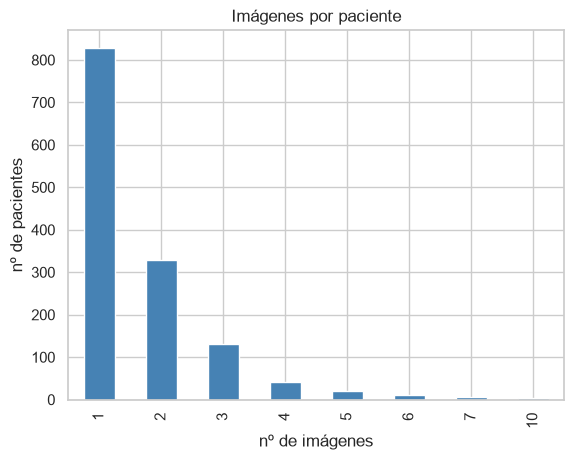

% de pacientes con más de una imagen: 39.6%


In [14]:
ax = per_patient["n_img"].value_counts().sort_index().plot(kind="bar", color="steelblue")
ax.set_title("Imágenes por paciente")
ax.set_xlabel("nº de imágenes"); ax.set_ylabel("nº de pacientes")
plt.show()

multi = (per_patient["n_img"] > 1).mean()
print(f"% de pacientes con más de una imagen: {multi*100:.1f}%")

## 8. Proporción de casos con biopsia

`biopsed` indica si el diagnóstico está confirmado por biopsia (ground truth más fuerte).

In [15]:
print(df["biopsed"].value_counts(dropna=False))
pd.crosstab(df["diagnostic"], df["biopsed"], normalize="index").round(2)

biopsed
True     1342
False     956
Name: count, dtype: int64


biopsed,False,True
diagnostic,,
ACK,0.76,0.24
BCC,0.00,1.00
MEL,0.00,1.00
NEV,0.75,0.25
SCC,0.00,1.00
SEK,0.94,0.06


## 9. Imágenes: tamaños

Las fotos son de smartphone, con tamaños variables → habrá que estandarizarlas para la CNN.

             width       height
count   300.000000   300.000000
mean    878.370000   878.220000
std     480.038028   480.126473
min     224.000000   224.000000
25%     495.750000   496.000000
50%     760.000000   760.000000
75%    1127.750000  1127.750000
max    2683.000000  2683.000000


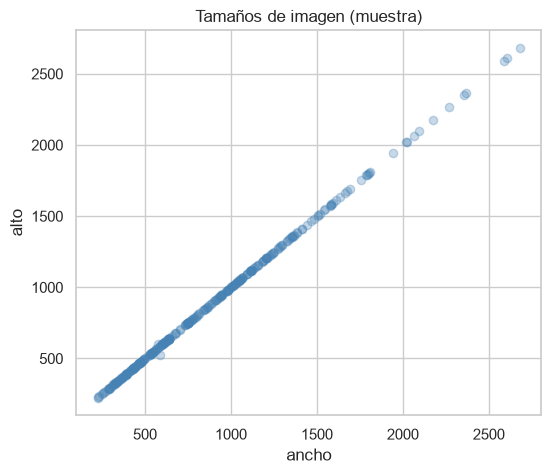

In [16]:
paths = df["img_path"].dropna().sample(min(300, df["img_path"].notna().sum()), random_state=0)
sizes = []
for p in paths:
    with Image.open(p) as im:
        sizes.append(im.size)
sizes = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes.describe())

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sizes["width"], sizes["height"], alpha=0.3, color="steelblue")
ax.set_xlabel("ancho"); ax.set_ylabel("alto"); ax.set_title("Tamaños de imagen (muestra)")
plt.show()

## 10. Muestra de imágenes por clase

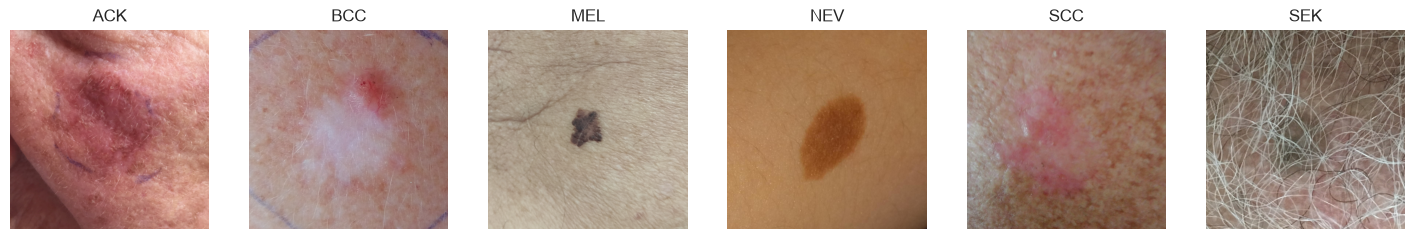

In [17]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    row = df[df["diagnostic"] == cls].iloc[0]
    with Image.open(row["img_path"]) as im:
        ax.imshow(im)
    ax.set_title(cls); ax.axis("off")
plt.show()

## 11. Conclusiones

- **Desbalance severo**: MEL (~52) frente a BCC (~845). Reportar macro-F1 / balanced accuracy y
  usar `class_weight` / focal loss; considerar augmentation más agresiva en clases minoritarias.
- **Split agrupado por paciente**: hay pacientes con varias imágenes → obligatorio agrupar por
  `patient_id` para evitar leakage. La estratificación por clase será aproximada por el grupo.
- **Valores faltantes** en varias columnas clínicas → definir imputación en `features/`.
- **Imágenes de tamaño variable** → redimensionar/normalizar en el preprocesamiento de imagen.
- **Señales clínicas** (síntomas, diámetro, edad) parecen aportar información → justifican el
  enfoque multimodal (tabular + imagen).